# 19 - Sector price map

> **Outrider notebook.** Demonstrates functionality built during this project, **not part of the original 16 CampusX notebooks**. Same framing as `00_data_collection` and `17_model_explainability`. This notebook covers the sector price map added later (CampusX called for "Tile Choropleth Maps"; there is no GeoJSON of informal Gurgaon sector boundaries, so this is a **bubble map** - `PROJECT_PLAN.md` Section 4).

Built by `src/features/geo.py` from `data/raw/latlong.csv` joined onto `gurgaon_properties_missing_value_imputation.csv`: one bubble per sector centroid, coloured by mean `price_per_sqft`, sized by mean `built_up_area`. Content recovered from the pre-cleanup `05_eda.ipynb` (Section 3.4, git history) and re-verified against the current `geo.py` - the join report and both figure builders run unchanged.

The interactive Plotly OpenStreetMap version (`build_sector_map`) renders **blank in Jupyter inline output** specifically (a MapLibre inline-renderer bug, verified - see `geo.py`), so - exactly as the live app does for its committed fallback - the figure shown here is the **matplotlib** one (`build_sector_map_static`).

In [1]:
import sys
from pathlib import Path
REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import warnings
warnings.simplefilter('ignore')
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100

## 0. Data being loaded

Visible confirmation this runs on the real project data.

In [2]:
_prop_path = REPO_ROOT / 'data/processed/gurgaon_properties_missing_value_imputation.csv'
_ll_path = REPO_ROOT / 'data/raw/latlong.csv'
_prop = pd.read_csv(_prop_path)
_ll = pd.read_csv(_ll_path)
print(f'Loaded {_prop_path.relative_to(REPO_ROOT)}: {len(_prop)} rows '
      f'({_prop["sector"].nunique()} sectors)')
print(f'Loaded {_ll_path.relative_to(REPO_ROOT)}: {len(_ll)} rows '
      f'({_ll["sector"].nunique()} sector coordinates)')

Loaded data\processed\gurgaon_properties_missing_value_imputation.csv: 3554 rows (104 sectors)
Loaded data\raw\latlong.csv: 129 rows (129 sector coordinates)


---
## The sector price map

The `price_per_sqft`-by-sector story is geographic: the money is in a contiguous eastern corridor. `sector_map_frame()` does the coordinate join and per-sector aggregation and returns `(group_df, join_report)`.

In [3]:
from src.features.geo import sector_map_frame, build_sector_map, build_sector_map_static

group_df, report = sector_map_frame(write_csv=False)   # write_csv=False: leave the committed
                                                      # data/processed/sector_price_map.csv untouched
print(json.dumps(report, indent=2, default=str))

{
  "n_input_rows": 3554,
  "n_joined_rows": 3383,
  "n_dropped_rows": 171,
  "n_sectors_input": 104,
  "n_exact_matches": 101,
  "n_fallback_matches": 1,
  "fallback_matches": {
    "sector 70a": "sector 70"
  },
  "unmatched_sectors": [
    "dwarka expressway",
    "sohna road"
  ],
  "dropped_rows_by_sector": {
    "dwarka expressway": 8,
    "sohna road": 163
  }
}


**Reading the join report:** 3,383 / 3,554 rows join. `sector 70a` is recovered by the trailing-letter fallback (`-> sector 70`). Two sectors stay unmatched because they are *road* names, not suffix variants: `sohna road` (163 rows, ~4.6 % - the one material loss) and `dwarka expressway` (8 rows). `latlong.csv` carries 129 sectors vs 104 in the data, so ~25 coordinate rows go unused - expected superset slack. 101 exact + 1 fallback = 102 sectors on the map.

In [4]:
group_df.sort_values('price_per_sqft', ascending=False).head(10)

,price,price_per_sqft,built_up_area,latitude,longitude,n_properties
sector,,,,,,
sector 26,11.81,31881.85,4026.10,28.48,77.10,40
sector 25,8.66,30650.00,3395.85,28.48,77.09,37
sector 27,6.12,28889.50,2196.00,28.47,77.09,2
sector 45,8.50,25525.50,2897.50,28.45,77.07,8
sector 41,6.14,24010.73,2971.82,28.46,77.06,11
sector 50,6.74,22964.82,3097.56,28.42,77.06,61
sector 38,3.89,22355.60,2056.30,28.43,77.04,10
sector 31,3.53,22197.30,1572.30,28.45,77.05,10
sector 43,5.86,21125.59,2470.22,28.46,77.08,58


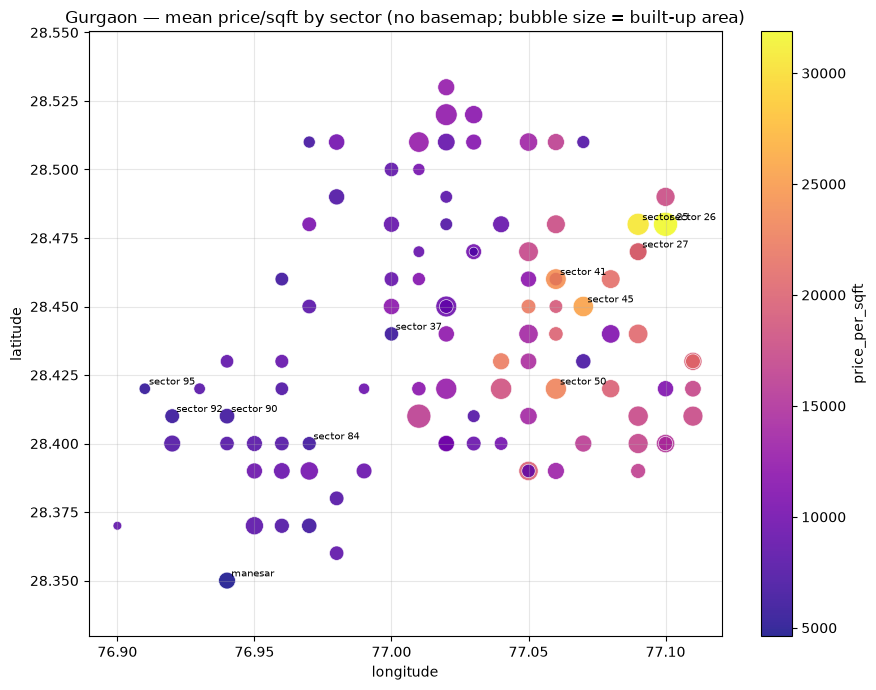

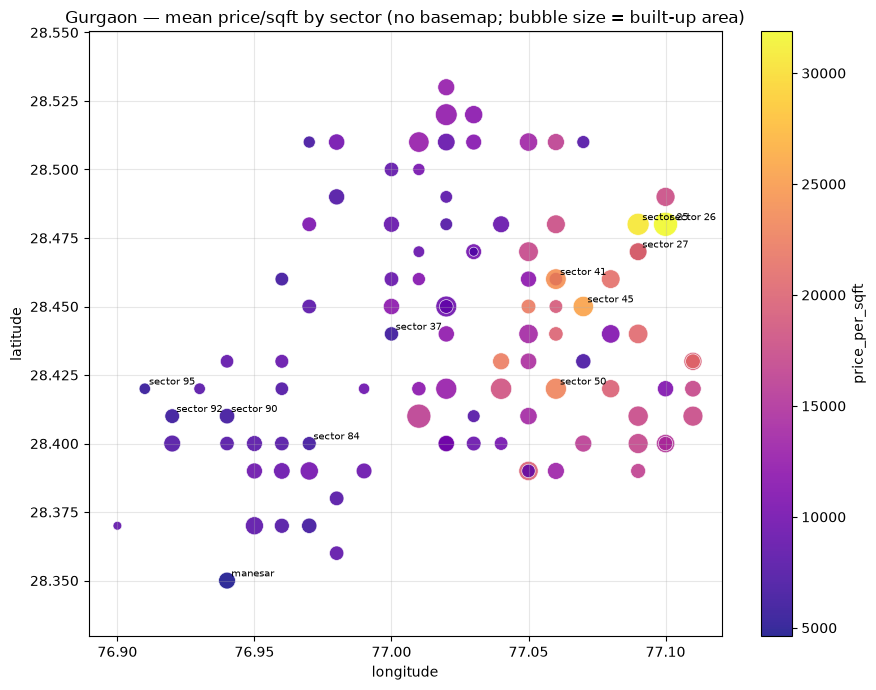

In [5]:
static_fig = build_sector_map_static(group_df)   # matplotlib; embeds in any viewer
static_fig

**Reading the map.** Price per sq ft falls off sharply east -> west. The bright band - sectors 24-28 and 41-54 plus the DLF phases - is the Golf Course Road / Golf Course Extension corridor (~Rs 22k-32k/sq ft). The dark western cluster - sectors 90 / 92 / 95 and Manesar - is New Gurgaon along the Dwarka Expressway belt (~Rs 4.6k-6k/sq ft). Bubble size (built-up area) is largest in the low-density eastern luxury sectors.

In [6]:
# The interactive Plotly OSM version - what the app renders. It draws blank
# in Jupyter inline output specifically (see geo.py), so we build it and
# report its shape rather than display it here.
fig = build_sector_map(group_df)
print(f'{type(fig).__name__}: {len(fig.data[0].lat)} sector bubbles '
      '(call fig.show() in a live kernel, or use it in the app).')

Figure: 102 sector bubbles (call fig.show() in a live kernel, or use it in the app).
